In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/h&n&l.csv'

try:
    hl_df = pd.read_csv(file_path)
    display(hl_df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}")
except Exception as e:
    print(f"An error occurred: {e}")

,InsureeID,PregnantBefore,MatibabuID,PPIScore,DecodedHealthConditions,DecodedComplications,Age,PPIScorevalue,PregnantBeforeScore,AgeScore,conditionScore,ComplicationRiskScore,SelectedTotalScore,RiskCategory
0,739797.0,2,152010241460,31.0,diabetes,diabetes,22,1,0,0,3,2,6,high risk
1,264546.0,0,152010642265,32.0,diabetes,NaN,19,0,0,1,3,0,4,normal risk
2,512467.0,2,151010681942,32.0,diabetes,diabetes,37,0,0,0,3,2,5,normal risk
3,284626.0,1,151020537286,40.0,diabetes,diabetes,30,0,0,0,3,2,5,normal risk
4,514947.0,1,151010258232,43.0,diabetes,diabetes,22,0,0,0,3,2,5,normal risk


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

df_processed = hl_df.drop(columns=['InsureeID', 'MatibabuID', 'DecodedHealthConditions', 'DecodedComplications']).dropna()

target_mapping = {'low risk': 0, 'normal risk': 1, 'high risk': 2}
df_processed['RiskCategory'] = df_processed['RiskCategory'].map(target_mapping)
# Select only the columns used for calculating SelectedTotalScore
X = df_processed[['ComplicationRiskScore', 'conditionScore', 'PPIScorevalue', 'AgeScore', 'PregnantBeforeScore']]
y = df_processed['RiskCategory']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preprocessing complete.")
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Data preprocessing complete.
Shape of X_train_scaled: (7237, 9)
Shape of X_test_scaled: (1810, 9)
Shape of y_train: (7237,)
Shape of y_test: (1810,)


In [ ]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(target_mapping), activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,819 (11.01 KB)

 Trainable params: 2,819 (11.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:

history = model.fit(X_train_scaled, y_train, epochs=30, validation_split=0.2)

print("Model training complete.")

Epoch 1/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.8630 - loss: 0.5065 - val_accuracy: 0.9938 - val_loss: 0.0436
Epoch 2/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9991 - loss: 0.0282 - val_accuracy: 1.0000 - val_loss: 0.0094
Epoch 3/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9999 - loss: 0.0072 - val_accuracy: 0.9993 - val_loss: 0.0046
Epoch 4/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9996 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 5/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9999 - loss: 0.0024 - val_accuracy: 1.0000 - val_loss: 0.0018
Epoch 6/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 0.0014
Epoch 7/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 1.0000 - loss: 9.4269e-04 - val_accuracy: 0.9986 - val_loss: 0.0073
Epoch 8/30
181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 1.0000 - loss: 7.5378e-04 - val_acc

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_scaled, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Get predictions on the test data
y_pred = np.argmax(model.predict(X_test_scaled), axis=-1)

# Generate and display the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

# Display classification report
class_report = classification_report(y_test, y_pred, target_names=target_mapping.keys())
print("\nClassification Report:")
print(class_report)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 1.8469e-05
Test Loss: 0.0000
Test Accuracy: 1.0000
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

Confusion Matrix:
[[217   0   0]
 [  0 904   0]
 [  0   0 689]]

Classification Report:
              precision    recall  f1-score   support

    low risk       1.00      1.00      1.00       217
 normal risk       1.00      1.00      1.00       904
   high risk       1.00      1.00      1.00       689

    accuracy                           1.00      1810
   macro avg       1.00      1.00      1.00      1810
weighted avg       1.00      1.00      1.00      1810



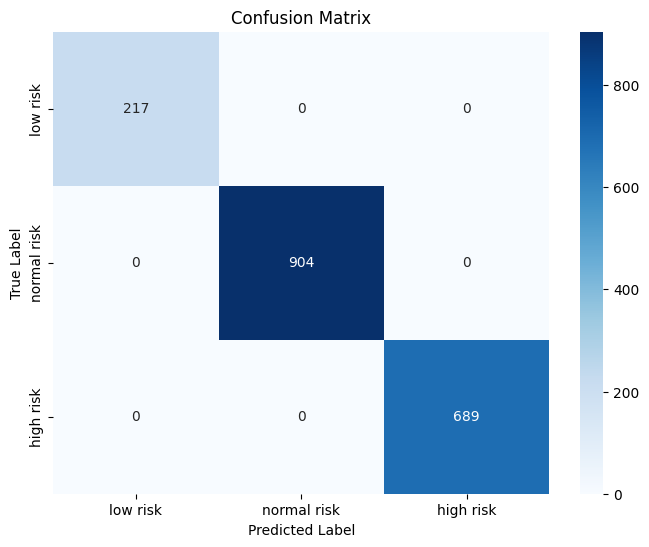

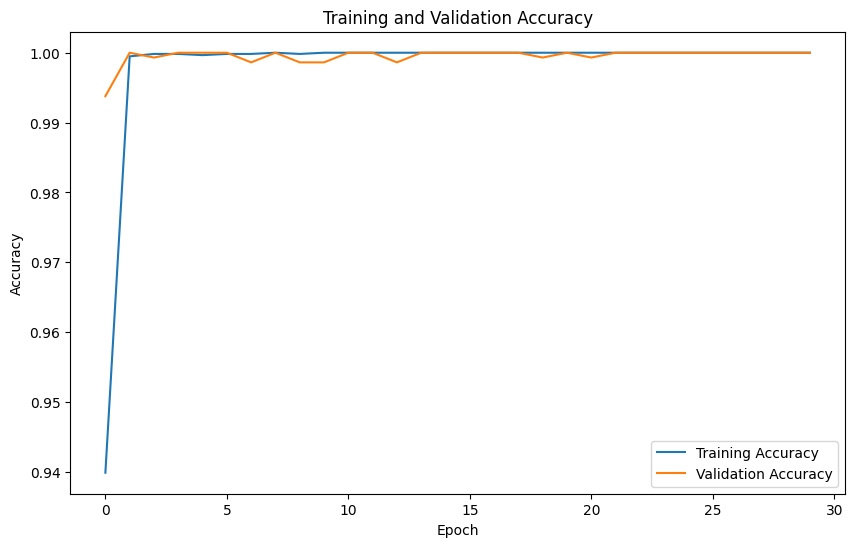

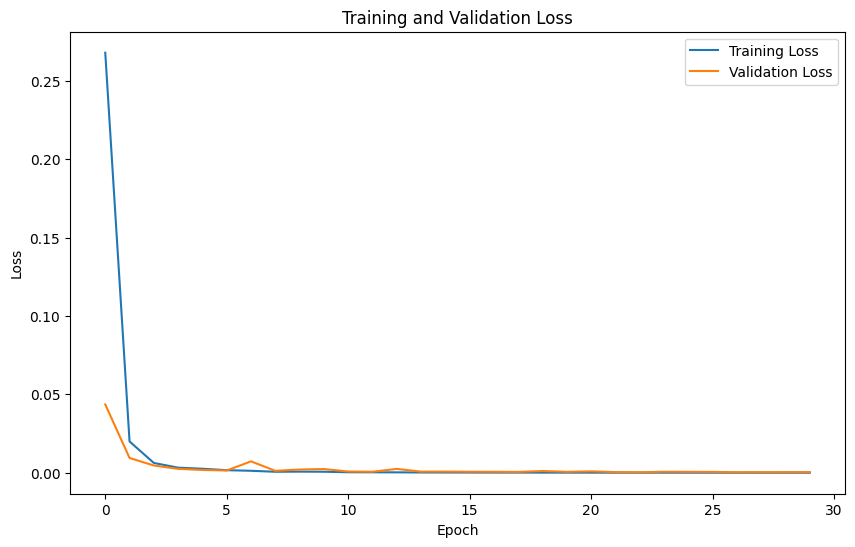

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_mapping.keys(), yticklabels=target_mapping.keys())
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Plot training and validation accuracy over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()